In [8]:
import torch
torch.cuda.is_available()


False

In [9]:
!pip install kaggle
!pip install pandas numpy matplotlib seaborn scikit-learn
!pip install tensorflow keras


In [2]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"devaranavyasree","key":"6db4c6e37b21410daa046411f84bd7ee"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [4]:
!kaggle datasets download -d msambare/fer2013
!unzip fer2013.zip


Streaming output truncated to the last 5000 lines.
  inflating: train/sad/Training_65242339.jpg  
  inflating: train/sad/Training_65267116.jpg  
  inflating: train/sad/Training_65275626.jpg  
  inflating: train/sad/Training_6529266.jpg  
  inflating: train/sad/Training_65329617.jpg  
  inflating: train/sad/Training_65338712.jpg  
  inflating: train/sad/Training_65338797.jpg  
  inflating: train/sad/Training_65387162.jpg  
  inflating: train/sad/Training_65404494.jpg  
  inflating: train/sad/Training_65426218.jpg  
  inflating: train/sad/Training_65430136.jpg  
  inflating: train/sad/Training_65437377.jpg  
  inflating: train/sad/Training_6545735.jpg  
  inflating: train/sad/Training_65463385.jpg  
  inflating: train/sad/Training_65473985.jpg  
  inflating: train/sad/Training_65502829.jpg  
  inflating: train/sad/Training_65505359.jpg  
  inflating: train/sad/Training_65508578.jpg  
  inflating: train/sad/Training_65516023.jpg  
  inflating: train/sad/Training_65524027.jpg  
  inflating

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
import zipfile

with zipfile.ZipFile('fer2013.zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Unzipped successfully!")


Unzipped successfully!


In [6]:
import os
os.listdir()


['.config', 'train', 'kaggle.json', 'test', 'fer2013.zip', 'sample_data']

In [7]:
import zipfile

with zipfile.ZipFile('fer2013.zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Unzipped successfully!")


Unzipped successfully!


In [8]:
import os
os.listdir()


['.config', 'train', 'kaggle.json', 'test', 'fer2013.zip', 'sample_data']

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [10]:
img_size = 48
batch_size = 32


In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'train',
    target_size=(img_size, img_size),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    'test',
    target_size=(img_size, img_size),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical'
)


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


===== FER DATASET SUMMARY =====
Train samples: 28709
Test samples: 7178
Number of classes: 7
Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}

===== TRAIN CLASS DISTRIBUTION =====
angry       3995
disgust      436
fear        4097
happy       7215
neutral     4965
sad         4830
surprise    3171
Name: count, dtype: int64

===== TEST CLASS DISTRIBUTION =====
angry        958
disgust      111
fear        1024
happy       1774
neutral     1233
sad         1247
surprise     831
Name: count, dtype: int64


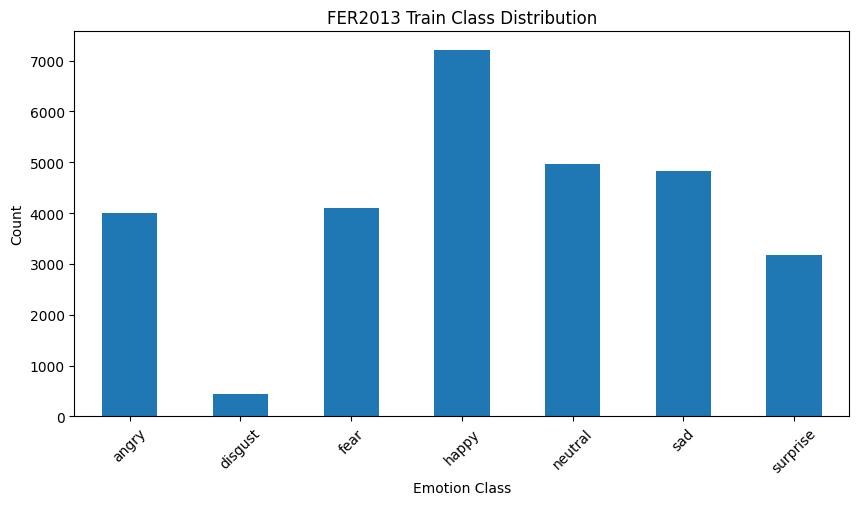


===== RANDOM TRAIN IMAGES =====


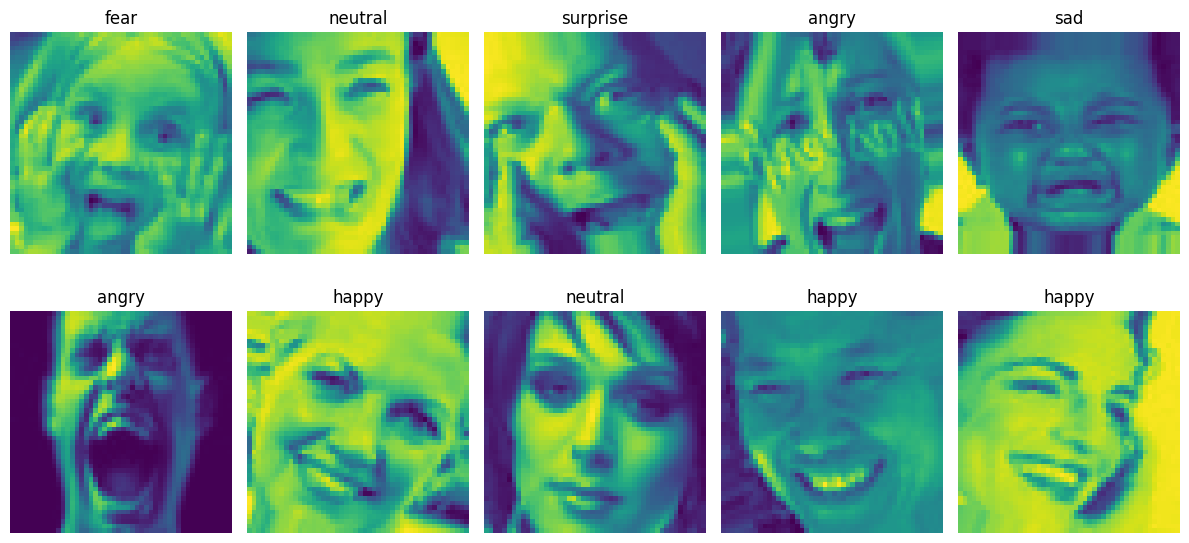


===== CLASS WEIGHTS (for training) =====
{0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


In [12]:
# ==============================
# Milestone 1 Completion (FER2013 Analysis)
# Paste AFTER train_generator and test_generator are created
# ==============================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# 1) Dataset summary
print("===== FER DATASET SUMMARY =====")
print("Train samples:", train_generator.samples)
print("Test samples:", test_generator.samples)
print("Number of classes:", train_generator.num_classes)
print("Class indices:", train_generator.class_indices)

# 2) Count samples per class
train_counts = pd.Series(train_generator.classes).value_counts().sort_index()
test_counts = pd.Series(test_generator.classes).value_counts().sort_index()

# Convert numeric labels to class names
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
train_counts.index = train_counts.index.map(idx_to_class)
test_counts.index = test_counts.index.map(idx_to_class)

print("\n===== TRAIN CLASS DISTRIBUTION =====")
print(train_counts)

print("\n===== TEST CLASS DISTRIBUTION =====")
print(test_counts)

# 3) Plot distribution
plt.figure(figsize=(10,5))
train_counts.plot(kind="bar")
plt.title("FER2013 Train Class Distribution")
plt.xlabel("Emotion Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# 4) Visualize sample images
print("\n===== RANDOM TRAIN IMAGES =====")
images, labels = next(train_generator)

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i])
    label_index = np.argmax(labels[i])
    plt.title(idx_to_class[label_index])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 5) OPTIONAL: Class weights for imbalance (good practice)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights_dict = dict(enumerate(class_weights))
print("\n===== CLASS WEIGHTS (for training) =====")
print(class_weights_dict)


In [13]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [14]:
print("Emotion Classes:", train_generator.class_indices)


Emotion Classes: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [15]:
!kaggle datasets download -d tadepalli/lastfm-dataset


403 Client Error: Forbidden for url: https://www.kaggle.com/api/v1/datasets/metadata/tadepalli/lastfm-dataset


In [ ]:
from google.colab import files
files.upload()


In [14]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!unzip "archive (2).zip"


In [ ]:
import pandas as pd

# Load music metadata
music_df = pd.read_csv("Music Info.csv")

# Load user listening history
history_df = pd.read_csv("User Listening History.csv")

print("Music Info Shape:", music_df.shape)
print("Listening History Shape:", history_df.shape)

music_df.head()



===== MUSIC DATASET SUMMARY =====
Shape: (21916, 21)

Columns:
Index(['track_id', 'name', 'artist', 'spotify_preview_url', 'spotify_id',
       'tags', 'genre', 'year', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature'],
      dtype='object')

After cleaning:
Shape: (21916, 21)

===== MISSING VALUES REPORT =====
track_id               0
name                   0
artist                 0
spotify_preview_url    0
spotify_id             0
tags                   0
genre                  0
year                   0
duration_ms            0
danceability           0
energy                 0
key                    0
loudness               0
mode                   0
speechiness            0
dtype: int64

===== TOP 15 GENRES =====
genre
rock          9817
electronic    3582
metal         2493
pop           1143
rap            813
jazz           781
rnb            690


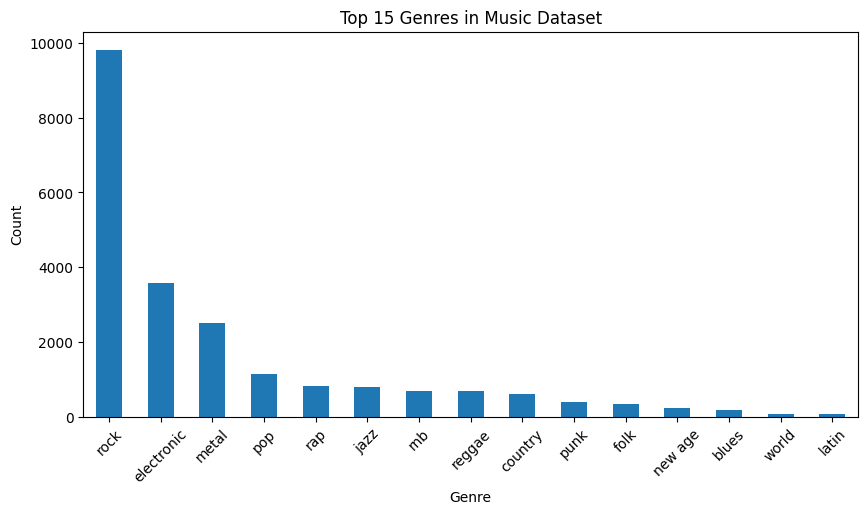


===== FINAL MUSIC DATASET READY =====
Shape: (7754, 2)
                   artist genre
2                 Nirvana   rnb
4               Radiohead   rnb
8                Coldplay  rock
10  Red Hot Chili Peppers   pop
12               Gorillaz   rnb


In [55]:
# ==============================
# Milestone 1 Completion (Music Dataset Cleaning + Feature Prep)
# Paste AFTER music_df is loaded
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("===== MUSIC DATASET SUMMARY =====")
print("Shape:", music_df.shape)
print("\nColumns:")
print(music_df.columns)

# 1) Basic cleaning
music_df = music_df.drop_duplicates()

# If genre column exists, clean it
if "genre" in music_df.columns:
    music_df["genre"] = music_df["genre"].astype(str).str.lower().str.strip()

# Remove empty genres if present
if "genre" in music_df.columns:
    music_df = music_df[music_df["genre"].notna()]
    music_df = music_df[music_df["genre"] != "nan"]
    music_df = music_df[music_df["genre"] != ""]
    music_df = music_df[music_df["genre"] != "none"]

print("\nAfter cleaning:")
print("Shape:", music_df.shape)

# 2) Missing values report
print("\n===== MISSING VALUES REPORT =====")
print(music_df.isnull().sum().sort_values(ascending=False).head(15))

# 3) Genre distribution (Top 15)
if "genre" in music_df.columns:
    print("\n===== TOP 15 GENRES =====")
    top_genres = music_df["genre"].value_counts().head(15)
    print(top_genres)

    plt.figure(figsize=(10,5))
    top_genres.plot(kind="bar")
    plt.title("Top 15 Genres in Music Dataset")
    plt.xlabel("Genre")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

# 4) Create a final clean music table (for recommendation)
important_cols = []

# Try to keep the best columns if they exist
for col in ["track_name", "artist", "title", "song", "track", "genre"]:
    if col in music_df.columns:
        important_cols.append(col)

final_music_df = music_df[important_cols].copy() if important_cols else music_df.copy()

# Rename common variants to standard names
rename_map = {}
if "title" in final_music_df.columns:
    rename_map["title"] = "track_name"
if "song" in final_music_df.columns:
    rename_map["song"] = "track_name"
if "track" in final_music_df.columns:
    rename_map["track"] = "track_name"

final_music_df = final_music_df.rename(columns=rename_map)

# Drop duplicates again
final_music_df = final_music_df.drop_duplicates()

print("\n===== FINAL MUSIC DATASET READY =====")
print("Shape:", final_music_df.shape)
print(final_music_df.head())


In [37]:
print(music_df.columns)
print(history_df.columns)


Index(['track_id', 'name', 'artist', 'spotify_preview_url', 'spotify_id',
       'tags', 'genre', 'year', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature'],
      dtype='object')
Index(['track_id', 'user_id', 'playcount'], dtype='object')


In [38]:
# Remove duplicates
music_df = music_df.drop_duplicates()

# Remove missing values
music_df = music_df.dropna()

print("After cleaning:", music_df.shape)


After cleaning: (21916, 21)


In [40]:
music_df.head()


,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4
8,TRMZXEW128F9341FD5,The Scientist,Coldplay,https://p.scdn.co/mp3-preview/95cb9df1b056d759...,0GSSsT9szp0rJkBrYkzy6s,"rock, alternative, indie, pop, alternative_roc...",Rock,2007,311014,0.566,...,5,-7.826,1,0.0242,0.715000,0.000014,0.1200,0.173,146.365,4
10,TRIODZU128E078F3E2,Under the Bridge,Red Hot Chili Peppers,https://p.scdn.co/mp3-preview/90e41778392f27b6...,06zh28PcYIFvNOAz5Wq2Xb,"rock, alternative, alternative_rock, 90s, funk",Pop,2003,265506,0.554,...,4,-8.046,1,0.0457,0.016800,0.000534,0.1360,0.513,84.275,4
12,TRYEZGE128F92D04C8,Feel Good Inc.,Gorillaz,https://p.scdn.co/mp3-preview/7388c425022ced92...,09xrHi86kLkEIzDLZiHNnv,"rock, electronic, alternative, indie, pop, alt...",RnB,2010,223106,0.809,...,6,-7.776,1,0.1360,0.033700,0.001410,0.8260,0.832,138.556,4


In [43]:
print(music_df.columns)


Index(['track_id', 'name', 'artist', 'spotify_preview_url', 'spotify_id',
       'tags', 'genre', 'year', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature'],
      dtype='object')


In [44]:
music_df.head()


,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4
8,TRMZXEW128F9341FD5,The Scientist,Coldplay,https://p.scdn.co/mp3-preview/95cb9df1b056d759...,0GSSsT9szp0rJkBrYkzy6s,"rock, alternative, indie, pop, alternative_roc...",Rock,2007,311014,0.566,...,5,-7.826,1,0.0242,0.715000,0.000014,0.1200,0.173,146.365,4
10,TRIODZU128E078F3E2,Under the Bridge,Red Hot Chili Peppers,https://p.scdn.co/mp3-preview/90e41778392f27b6...,06zh28PcYIFvNOAz5Wq2Xb,"rock, alternative, alternative_rock, 90s, funk",Pop,2003,265506,0.554,...,4,-8.046,1,0.0457,0.016800,0.000534,0.1360,0.513,84.275,4
12,TRYEZGE128F92D04C8,Feel Good Inc.,Gorillaz,https://p.scdn.co/mp3-preview/7388c425022ced92...,09xrHi86kLkEIzDLZiHNnv,"rock, electronic, alternative, indie, pop, alt...",RnB,2010,223106,0.809,...,6,-7.776,1,0.1360,0.033700,0.001410,0.8260,0.832,138.556,4


In [45]:
['song', 'artist', 'genre']


['song', 'artist', 'genre']

In [56]:
def recommend_by_genre(genre_name, n=10):
    genre_name = str(genre_name).lower().strip()

    # Clean genre column safely
    music_df["genre_clean"] = music_df["genre"].astype(str).str.lower().str.strip()

    # Use contains instead of ==
    filtered = music_df[music_df["genre_clean"].str.contains(genre_name, na=False)]

    if filtered.empty:
        return f"No songs found for genre containing: '{genre_name}'"

    return filtered.head(n)


In [57]:
recommend_by_genre("pop")


,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,genre_clean
10,TRIODZU128E078F3E2,Under the Bridge,Red Hot Chili Peppers,https://p.scdn.co/mp3-preview/90e41778392f27b6...,06zh28PcYIFvNOAz5Wq2Xb,"rock, alternative, alternative_rock, 90s, funk",pop,2003,265506,0.554,...,-8.046,1,0.0457,0.016800,0.000534,0.1360,0.513,84.275,4,pop
39,TRAOMFT128F42A7684,Losing My Religion,R.E.M.,https://p.scdn.co/mp3-preview/7e795b53f58d926a...,04pRvt8HcPmmP6EeZoYMxa,"rock, alternative, indie, pop, alternative_roc...",pop,2014,288160,0.668,...,-10.753,0,0.0277,0.011500,0.000259,0.3370,0.629,126.978,4,pop
93,TRRVVTK128F422BB5D,Don't Stop Me Now,Queen,https://p.scdn.co/mp3-preview/6042b8adbf1102b2...,0ch4H0B6RvfOvpI47YXyre,"rock, classic_rock, 80s, british, 70s",pop,1979,268173,0.450,...,-11.825,1,0.1940,0.050200,0.000241,0.6890,0.230,159.335,4,pop
94,TROCLWN128F92EB284,Fluorescent Adolescent,Arctic Monkeys,https://p.scdn.co/mp3-preview/cb8560b45aa0d402...,02Y78WneC8bUaKWouKl00v,"rock, alternative, indie, alternative_rock, in...",pop,2007,177534,0.647,...,-5.222,0,0.0291,0.001960,0.000030,0.1770,0.813,112.109,4,pop
312,TRADJBK128F1453605,In Too Deep,Sum 41,https://p.scdn.co/mp3-preview/66eca3757c201239...,0GH52eIynfyKDPDGWHvRan,"rock, alternative, alternative_rock, punk, pun...",pop,2010,206493,0.569,...,-6.819,1,0.0593,0.000217,0.000000,0.0644,0.755,116.013,4,pop
404,TRILYBE128F428923B,Perfect Day,Lou Reed,https://p.scdn.co/mp3-preview/a48050121ba5ec0d...,003n4ftz70WFRbPyuBd9a3,"rock, classic_rock, singer_songwriter, soundtr...",pop,1972,224600,0.390,...,-15.740,1,0.0327,0.688000,0.000412,0.1020,0.106,147.270,3,pop
437,TRXFYTA128F429364C,Wild Horses,The Rolling Stones,https://p.scdn.co/mp3-preview/95f9ab1dad3bb25b...,1hsrmBpddP05q7XvJA8ehw,"rock, classic_rock, british, 70s, blues_rock",pop,2011,344386,0.443,...,-9.750,1,0.0267,0.666000,0.000785,0.0813,0.178,140.749,4,pop
489,TRCVUEM12903CB61A2,Ticket to Ride,The Beatles,https://p.scdn.co/mp3-preview/f136a4923ab251ca...,2gf83374sa2JqtrYxGYdPU,"rock, pop, classic_rock, british, 60s, oldies",pop,2008,193120,0.500,...,-18.803,0,0.0655,0.014900,0.000000,0.2350,0.570,123.460,4,pop
560,TRWIKBF128F92DD506,Goodbye My Lover,James Blunt,https://p.scdn.co/mp3-preview/f9126a8531cc8006...,0Iit3mwdeG3aIcK4kOviUo,"rock, alternative, indie, pop, singer_songwrit...",pop,2012,258373,0.412,...,-10.079,1,0.0546,0.950000,0.003880,0.0944,0.265,79.907,3,pop
580,TRDBHKC128F42A3A97,You Found Me,The Fray,https://p.scdn.co/mp3-preview/4d14eda64e96e13b...,0JBBvihPCdRiq1YPds4VYI,"rock, alternative, indie, pop, alternative_roc...",pop,2003,243733,0.336,...,-5.411,0,0.0420,0.019100,0.000000,0.1340,0.395,152.074,4,pop


In [48]:
def recommend_by_emotion(emotion):
    genre = emotion_to_genre.get(emotion)
    return recommend_by_genre(genre)

recommend_by_emotion("happy")


,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature


In [49]:
print(music_df.columns)


Index(['track_id', 'name', 'artist', 'spotify_preview_url', 'spotify_id',
       'tags', 'genre', 'year', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature'],
      dtype='object')


In [50]:
print(music_df['genre'].unique())


['RnB' 'Rock' 'Pop' 'Metal' 'Electronic' 'Jazz' 'Punk' 'Country' 'Folk'
 'Reggae' 'Rap' 'Blues' 'New Age' 'Latin' 'World']


In [4]:
emotion_to_genre = {
    "happy": "pop",
    "sad": "acoustic",
    "angry": "metal",
    "neutral": "classical",
    "surprise": "dance",
    "fear": "ambient",
    "disgust": "rock"
}


In [5]:
def recommend_by_emotion(emotion, n=10):
    emotion = emotion.lower().strip()
    genre = emotion_to_genre.get(emotion)

    if genre is None:
        return f"Emotion '{emotion}' not mapped."

    # Make genre matching case-insensitive
    music_df["genre_clean"] = music_df["genre"].astype(str).str.lower().str.strip()

    filtered = music_df[music_df["genre_clean"] == genre.lower().strip()]

    if filtered.empty:
        return f"No songs found for genre '{genre}'. Try another mapping."

    return filtered.sample(min(n, len(filtered)))


In [6]:
recommend_by_emotion("happy")


NameError: name 'music_df' is not defined